# Optuna Results

Use this notebook to inspect the best hyperparameter trials for each model.

The project Optuna runner is multi-objective:

- maximize `mean_reward`
- minimize `mean_fluidity`

So there are two useful views:

- **Best by reward:** the single highest-reward completed trial for each model.
- **Pareto front:** trials that are not dominated when considering both reward and fluidity.

In [1]:
from pathlib import Path

import optuna
import pandas as pd
import yaml
from optuna.trial import TrialState

c:\Users\prajapaa\AppData\Local\anaconda3\envs\worldmodel\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Find the repo root from either the notebook folder or project folder."""
    current = (start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "configs" / "tuning").exists() and (
            path / "optuna_studies"
        ).exists():
            return path
    raise FileNotFoundError(
        "Could not find project root with configs/tuning and optuna_studies."
    )


PROJECT_ROOT = find_project_root()
TUNING_DIR = PROJECT_ROOT / "configs" / "tuning"

PROJECT_ROOT

WindowsPath('C:/Users/prajapaa/OneDrive - The University of Colorado Denver/PHD/Courses/CSCI_5931_DL/project/DeepLearningWorldModelProject')

## Load Studies

In [3]:
def resolve_storage_uri(storage: str, project_root: Path) -> str:
    if not storage.startswith("sqlite:///"):
        return storage

    db_path = Path(storage.replace("sqlite:///", ""))
    if not db_path.is_absolute():
        db_path = project_root / db_path
    return f"sqlite:///{db_path.as_posix()}"


def load_optuna_studies(tuning_dir: Path, project_root: Path) -> dict[str, dict]:
    studies = {}

    for cfg_path in sorted(tuning_dir.glob("optuna_*.yaml")):
        with cfg_path.open("r", encoding="utf-8") as f:
            cfg = yaml.safe_load(f)

        optuna_cfg = cfg["optuna"]
        baseline_key = optuna_cfg["baseline_key"]
        storage = resolve_storage_uri(optuna_cfg["storage"], project_root)

        study = optuna.load_study(
            study_name=optuna_cfg["study_name"],
            storage=storage,
        )

        studies[baseline_key] = {
            "config_path": cfg_path,
            "optuna_config": optuna_cfg,
            "study": study,
        }

    return studies


studies = load_optuna_studies(TUNING_DIR, PROJECT_ROOT)
list(studies)

['ppo',
 'ppo_lstm',
 'ppo_resnet18',
 'ppo_resnet18_ft',
 'ppo_resnet18_lstm',
 'ppo_resnet18_lstm_ft']

## Best Trial by Reward

This selects the completed trial with the highest `mean_reward` for each model.

In [4]:
def completed_trials(study: optuna.Study) -> list[optuna.trial.FrozenTrial]:
    return [
        trial
        for trial in study.trials
        if trial.state == TrialState.COMPLETE and trial.values is not None
    ]


rows = []
for model_name, entry in studies.items():
    trials = completed_trials(entry["study"])
    if not trials:
        rows.append({"model": model_name, "status": "no completed trials"})
        continue

    best = max(trials, key=lambda trial: trial.values[0])
    rows.append(
        {
            "model": model_name,
            "trial": best.number,
            "mean_reward": best.values[0],
            "mean_fluidity": best.values[1],
            "params": best.params,
            "success_rate": best.user_attrs.get("success_rate"),
            "mean_distance": best.user_attrs.get("mean_distance"),
            "std_reward": best.user_attrs.get("std3.0e-4_reward"),
            "config_path": str(entry["config_path"].relative_to(PROJECT_ROOT)),
        }
    )

best_by_reward = pd.DataFrame(rows).sort_values("mean_reward", ascending=False)
best_by_reward

,model,trial,mean_reward,mean_fluidity,params,success_rate,mean_distance,std_reward,config_path
1,ppo_lstm,9,395.116753,11640.980666,"{'learning_rate': 0.0003, 'n_steps': 512, 'lst...",0.6,0.038204,None,configs\tuning\optuna_ppo_lstm.yaml
0,ppo,3,168.222769,5352.007884,"{'learning_rate': 0.0003, 'n_steps': 512}",0.0,0.141668,None,configs\tuning\optuna_ppo.yaml
5,ppo_resnet18_lstm_ft,8,144.052082,19173.591433,"{'learning_rate': 0.0003, 'n_steps': 512, 'lst...",0.0,0.107689,None,configs\tuning\optuna_ppo_resnet18_lstm_ft.yaml
3,ppo_resnet18_ft,3,40.598641,137.566977,"{'learning_rate': 5e-05, 'n_steps': 1024, 'unf...",0.0,0.177881,None,configs\tuning\optuna_ppo_resnet18_ft.yaml
4,ppo_resnet18_lstm,2,36.926354,893.879010,"{'learning_rate': 0.0003, 'n_steps': 1024, 'ls...",0.0,0.193151,None,configs\tuning\optuna_ppo_resnet18_lstm.yaml
2,ppo_resnet18,0,27.355740,1171.845830,"{'learning_rate': 5e-05, 'n_steps': 512}",0.0,0.252820,None,configs\tuning\optuna_ppo_resnet18.yaml


## Pareto Front

These are the trials Optuna considers best when balancing both objectives.

In [5]:
rows = []
for model_name, entry in studies.items():
    study = entry["study"]
    for trial in study.best_trials:
        rows.append(
            {
                "model": model_name,
                "trial": trial.number,
                "mean_reward": trial.values[0],
                "mean_fluidity": trial.values[1],
                "params": trial.params,
                "success_rate": trial.user_attrs.get("success_rate"),
                "mean_distance": trial.user_attrs.get("mean_distance"),
                "std_reward": trial.user_attrs.get("std_reward"),
            }
        )

pareto_front = pd.DataFrame(rows).sort_values(
    ["model", "mean_reward"], ascending=[True, False]
)
pareto_front

,model,trial,mean_reward,mean_fluidity,params,success_rate,mean_distance,std_reward
1,ppo,3,168.222769,5352.007884,"{'learning_rate': 0.0003, 'n_steps': 512}",0.0,0.141668,125.149199
0,ppo,2,87.468001,46.192424,"{'learning_rate': 0.0001, 'n_steps': 512}",0.0,0.131809,48.806436
2,ppo,5,14.614992,39.121845,"{'learning_rate': 5e-05, 'n_steps': 512}",0.0,0.253261,7.333734
7,ppo_lstm,9,395.116753,11640.980666,"{'learning_rate': 0.0003, 'n_steps': 512, 'lst...",0.6,0.038204,73.860482
6,ppo_lstm,8,214.718455,4068.381988,"{'learning_rate': 0.0003, 'n_steps': 256, 'lst...",0.0,0.104691,49.725738
3,ppo_lstm,2,175.355876,832.742070,"{'learning_rate': 0.0001, 'n_steps': 512, 'lst...",0.0,0.209726,94.351809
5,ppo_lstm,4,147.802990,106.105939,"{'learning_rate': 0.0001, 'n_steps': 256, 'lst...",0.0,0.198839,127.325815
4,ppo_lstm,3,13.895284,67.779361,"{'learning_rate': 0.0001, 'n_steps': 256, 'lst...",0.0,0.381463,10.414036
8,ppo_resnet18,0,27.355740,1171.845830,"{'learning_rate': 5e-05, 'n_steps': 512}",0.0,0.252820,13.728554
9,ppo_resnet18_ft,3,40.598641,137.566977,"{'learning_rate': 5e-05, 'n_steps': 1024, 'unf...",0.0,0.177881,17.207080


## All Completed Trials

Use this table to compare every completed trial across models.

In [6]:
rows = []
for model_name, entry in studies.items():
    for trial in completed_trials(entry["study"]):
        rows.append(
            {
                "model": model_name,
                "trial": trial.number,
                "mean_reward": trial.values[0],
                "mean_fluidity": trial.values[1],
                "params": trial.params,
                "success_rate": trial.user_attrs.get("success_rate"),
                "mean_distance": trial.user_attrs.get("mean_distance"),
                "std_reward": trial.user_attrs.get("std_reward"),
            }
        )

all_trials = pd.DataFrame(rows).sort_values(
    ["model", "mean_reward"], ascending=[True, False]
)
all_trials

,model,trial,mean_reward,mean_fluidity,params,success_rate,mean_distance,std_reward
3,ppo,3,168.222769,5352.007884,"{'learning_rate': 0.0003, 'n_steps': 512}",0.0,0.141668,125.149199
2,ppo,2,87.468001,46.192424,"{'learning_rate': 0.0001, 'n_steps': 512}",0.0,0.131809,48.806436
0,ppo,0,32.626938,2550.842096,"{'learning_rate': 0.0003, 'n_steps': 512}",0.0,0.312565,59.435220
1,ppo,1,22.568167,150.229170,"{'learning_rate': 5e-05, 'n_steps': 512}",0.0,0.312152,7.983693
4,ppo,4,16.637483,58.423241,"{'learning_rate': 5e-05, 'n_steps': 256}",0.0,0.268187,5.186085
5,ppo,5,14.614992,39.121845,"{'learning_rate': 5e-05, 'n_steps': 512}",0.0,0.253261,7.333734
15,ppo_lstm,9,395.116753,11640.980666,"{'learning_rate': 0.0003, 'n_steps': 512, 'lst...",0.6,0.038204,73.860482
7,ppo_lstm,1,321.163474,11863.446630,"{'learning_rate': 0.0003, 'n_steps': 256, 'lst...",0.0,0.048730,33.336626
14,ppo_lstm,8,214.718455,4068.381988,"{'learning_rate': 0.0003, 'n_steps': 256, 'lst...",0.0,0.104691,49.725738
6,ppo_lstm,0,181.058684,4507.481197,"{'learning_rate': 0.0003, 'n_steps': 512, 'lst...",0.0,0.145982,64.220198


## Inspect One Model

Change `MODEL_NAME` to focus on one baseline.

In [7]:
MODEL_NAME = "ppo_resnet18_lstm_ft"

all_trials[all_trials["model"] == MODEL_NAME].reset_index(drop=True)

,model,trial,mean_reward,mean_fluidity,params,success_rate,mean_distance,std_reward
0,ppo_resnet18_lstm_ft,8,144.052082,19173.591433,"{'learning_rate': 0.0003, 'n_steps': 512, 'lst...",0.0,0.107689,71.529025
1,ppo_resnet18_lstm_ft,7,50.723295,441.362106,"{'learning_rate': 0.0003, 'n_steps': 1024, 'ls...",0.0,0.186185,23.074999
2,ppo_resnet18_lstm_ft,2,46.230263,64.761918,"{'learning_rate': 5e-05, 'n_steps': 1024, 'lst...",0.0,0.190787,27.800259
3,ppo_resnet18_lstm_ft,0,18.130836,94.337430,"{'learning_rate': 0.0003, 'n_steps': 1024, 'ls...",0.0,0.349238,17.266084
4,ppo_resnet18_lstm_ft,9,17.263561,227.284432,"{'learning_rate': 5e-05, 'n_steps': 512, 'lstm...",0.0,0.275598,7.277155
5,ppo_resnet18_lstm_ft,5,12.542865,116.007966,"{'learning_rate': 0.0001, 'n_steps': 1024, 'ls...",0.0,0.287901,6.616570
6,ppo_resnet18_lstm_ft,3,12.284813,363.026035,"{'learning_rate': 5e-05, 'n_steps': 512, 'lstm...",0.0,0.294565,9.100734
7,ppo_resnet18_lstm_ft,6,10.682270,223.636606,"{'learning_rate': 0.0001, 'n_steps': 1024, 'ls...",0.0,0.342849,4.106234
8,ppo_resnet18_lstm_ft,1,7.578475,291.546352,"{'learning_rate': 5e-05, 'n_steps': 512, 'lstm...",0.0,0.590734,3.750535
9,ppo_resnet18_lstm_ft,4,2.145649,559.396935,"{'learning_rate': 0.0001, 'n_steps': 1024, 'ls...",0.0,0.466325,1.141718


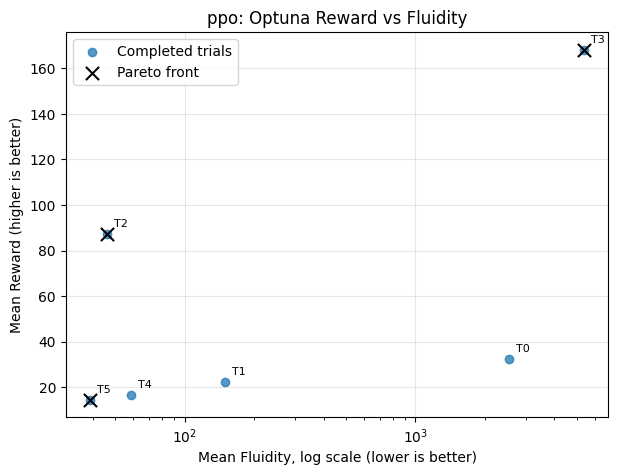

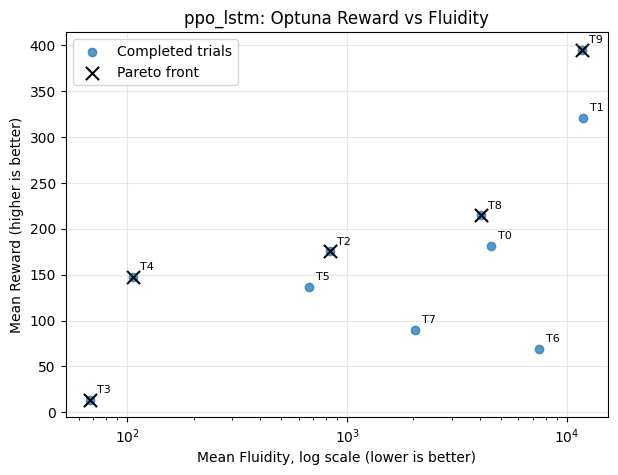

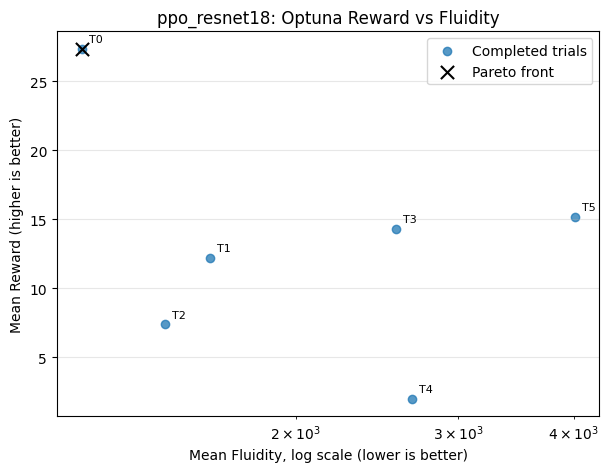

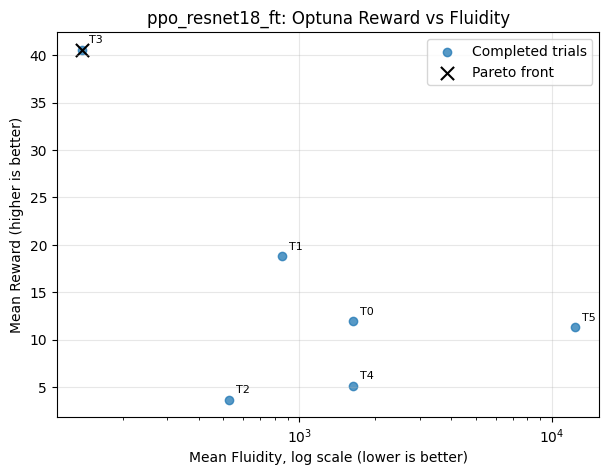

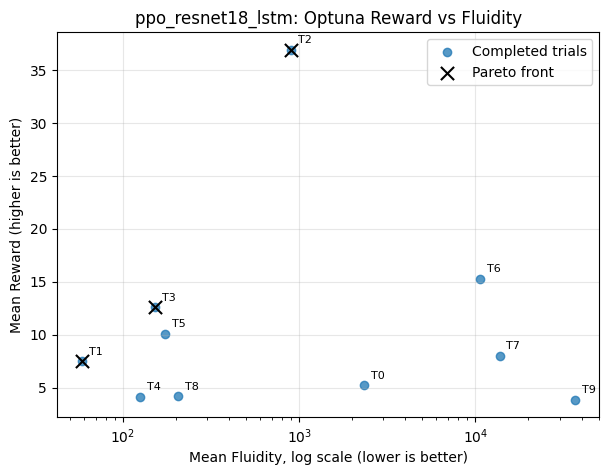

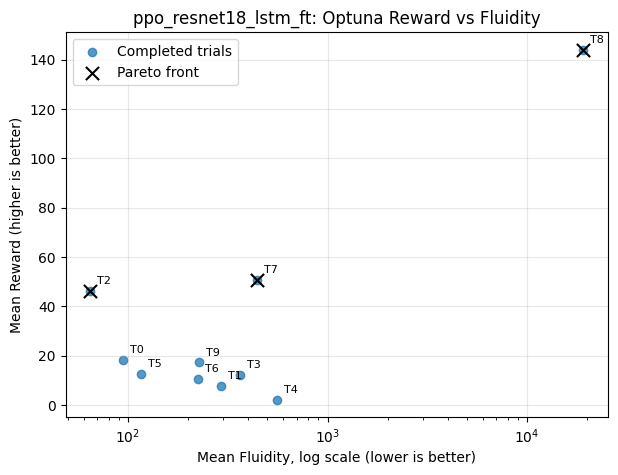

In [8]:
import matplotlib.pyplot as plt

for model_name, group in all_trials.groupby("model"):
    model_front = pareto_front[pareto_front["model"] == model_name]

    plt.figure(figsize=(7, 5))

    plt.scatter(
        group["mean_fluidity"],
        group["mean_reward"],
        alpha=0.75,
        label="Completed trials",
    )

    plt.scatter(
        model_front["mean_fluidity"],
        model_front["mean_reward"],
        color="black",
        marker="x",
        s=90,
        label="Pareto front",
    )

    for _, row in group.iterrows():
        plt.annotate(
            f"T{int(row['trial'])}",
            (row["mean_fluidity"], row["mean_reward"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

    plt.xscale("log")
    plt.xlabel("Mean Fluidity, log scale (lower is better)")
    plt.ylabel("Mean Reward (higher is better)")
    plt.title(f"{model_name}: Optuna Reward vs Fluidity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [9]:
def flatten_best_config_table(best_by_reward: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in best_by_reward.iterrows():
        params = dict(row["params"])

        rows.append(
            {
                "Model": row["model"],
                "Best trial": int(row["trial"]),
                "Learning rate": params.get("learning_rate"),
                "n_steps": params.get("n_steps"),
                "LSTM hidden size": params.get("lstm_hidden_size", ""),
                "Unfrozen layers": params.get("unfreeze_layers", ""),
                "Mean reward": row["mean_reward"],
                "Mean distance": row["mean_distance"],
                "Success rate": row["success_rate"],
                "Mean fluidity": row["mean_fluidity"],
            }
        )

    return pd.DataFrame(rows)


best_config_table = flatten_best_config_table(best_by_reward)
best_config_table

,Model,Best trial,Learning rate,n_steps,LSTM hidden size,Unfrozen layers,Mean reward,Mean distance,Success rate,Mean fluidity
0,ppo_lstm,9,0.00030,512,256,,395.116753,0.038204,0.6,11640.980666
1,ppo,3,0.00030,512,,,168.222769,0.141668,0.0,5352.007884
2,ppo_resnet18_lstm_ft,8,0.00030,512,256,layer4,144.052082,0.107689,0.0,19173.591433
3,ppo_resnet18_ft,3,0.00005,1024,,layer4,40.598641,0.177881,0.0,137.566977
4,ppo_resnet18_lstm,2,0.00030,1024,256,,36.926354,0.193151,0.0,893.879010
5,ppo_resnet18,0,0.00005,512,,,27.355740,0.252820,0.0,1171.845830


In [10]:
report_best_config_table = best_config_table.copy()

for col in ["Mean reward", "Mean distance", "Success rate", "Mean fluidity"]:
    report_best_config_table[col] = report_best_config_table[col].round(3)

report_best_config_table

,Model,Best trial,Learning rate,n_steps,LSTM hidden size,Unfrozen layers,Mean reward,Mean distance,Success rate,Mean fluidity
0,ppo_lstm,9,0.00030,512,256,,395.117,0.038,0.6,11640.981
1,ppo,3,0.00030,512,,,168.223,0.142,0.0,5352.008
2,ppo_resnet18_lstm_ft,8,0.00030,512,256,layer4,144.052,0.108,0.0,19173.591
3,ppo_resnet18_ft,3,0.00005,1024,,layer4,40.599,0.178,0.0,137.567
4,ppo_resnet18_lstm,2,0.00030,1024,256,,36.926,0.193,0.0,893.879
5,ppo_resnet18,0,0.00005,512,,,27.356,0.253,0.0,1171.846


In [11]:
report_best_config_table.to_csv(
    PROJECT_ROOT / "results_best_optuna_configs.csv",
    index=False,
)